In [1]:
# Center source alibration data and miniPET geometry directories
center_source_data_dir = 'C:/Users/burri/Downloads/MiniPET_Test_100mm_15min_coinc.dat'
miniPET_geo_map_dir = 'C:/Users/burri/Downloads/testMiniPETmap.csv' # Only used if generate_coincidence_heatmaps = True
output_dir = 'C:/Users/burri/Downloads/calibrationtest'

# Use gaussian fit to find mean for time offset, otherwise use simple weighted average around max
# Weighted average has minimal loss in accuracy (< 5%) but improves computation time drastically
use_guassian_fit = True
# Sample size threshold, will only perform fit or weighted average for each table entry if sample size is above this value
sample_size_threshold = 0
# Bin range above and below peak for weighted average
binrange = 5 # Only used if use_gaussian_fit = False

# Plots to be generated
# Generate before and after calibration time difference histograms with basic gaussian fit
generate_time_difference_histograms = True
# Generate before and after coincidence heatmaps
generate_coincidence_heatmaps = True

import numpy as np
import pandas as pd
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

In [ ]:
# Read calibration data into pd DataFrame
df = pd.DataFrame()
for chunk in pd.read_csv(center_source_data_dir, usecols=[2, 3, 4, 7, 8, 9], delimiter="\t", header=None, chunksize=10000):
    # Name columns
    chunk.columns = ['TimeL', 'EnergyL', 'IDL', 'TimeR', 'EnergyR', 'IDR']
    # Convert Left channel to mod 128
    chunk['IDL'] = chunk['IDL'] % 128
    # Time difference column
    chunk['TimeDiff'] = chunk['TimeR'] - chunk['TimeL']
    
    df = pd.concat([df, chunk], ignore_index=True)

# Convert to numpy array, faster
arr = df.to_numpy()

7


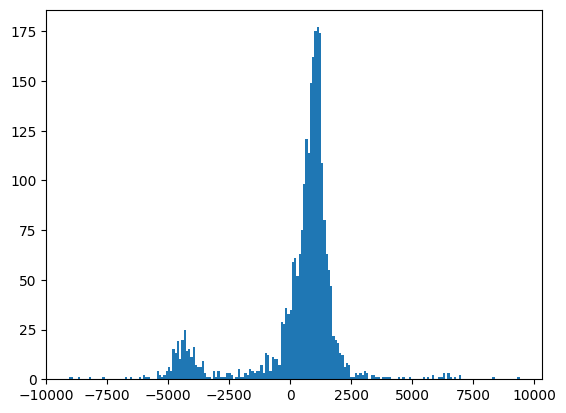

In [ ]:
# Array for storing left module channel time offsets 
coincidences_arr_l = [[] for i in range(128)]
coincidences_arr_r = [[] for i in range(128)]

# Creates coincidence matrix containing TimeDiffs for every LOR 
for x in range(len(arr)):
    coincidences_arr_l[int(arr[x][2])].append(arr[x][6])
    coincidences_arr_r[int(arr[x][5])].append(arr[x][6])



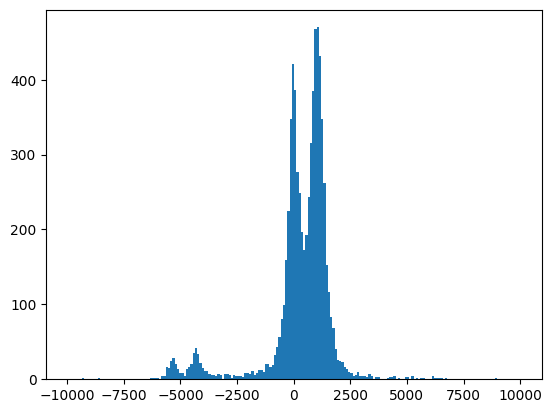

In [50]:
plt.hist(coincidences_arr_l[2], bins = 200)
plt.show()

In [43]:
# Create lookup table for each channel in l and r
lookup_l = np.asarray([0.0 for i in range(128)])
lookup_r = np.asarray([0.0 for i in range(128)])

# Define gaussian fit
def gaussian(x, a, mu, c):
    return a * np.exp(-(x - mu)**2 / (2 * c**2))

# Left side
for l in range(128):
#for l in [0]:
    # Create histogram
    counts, bins = np.histogram(coincidences_arr_l[l], bins = 200)
    # Initial guess for amplitude
    inita = 0.8 * np.max(counts)
    # Initial guess for mean
    initmu = bins[:-1][np.where(counts == np.max(counts))[0][0]]
                
    try:
        # try fit, with bad stats the fit sometimes doesn't work
        popt = curve_fit(gaussian, bins[:-1], counts, p0 = [inita, initmu, 500])[0]
        # Check that mean is reasonable 
        if abs(popt[1]) < 10000: # 10000
            # write time offset to table as negative so that it can be ADDED when used
            lookup_l[l] = popt[1]
    except:
        pass

    #plt.hist(coincidences_arr_l[l], bins = 200)
    #plt.plot(np.linspace(-10000, 10000, 300), gaussian(np.linspace(-10000, 10000, 300), *popt), color = 'black')
    #print(*popt)

# Right side
for r in range(128):
#for l in [0]:
    # Create histogram
    counts, bins = np.histogram(coincidences_arr_r[r], bins = 200)
    # Initial guess for amplitude
    inita = 0.8 * np.max(counts)
    # Initial guess for mean
    initmu = bins[:-1][np.where(counts == np.max(counts))[0][0]]
                
    try:
        # try fit, with bad stats the fit sometimes doesn't work
        popt = curve_fit(gaussian, bins[:-1], counts, p0 = [inita, initmu, 500])[0]
        # Check that mean is reasonable 
        if abs(popt[1]) < 10000: # 10000
            # write time offset to table as negative so that it can be ADDED when used
            lookup_r[r] = popt[1]
    except:
        pass

    #plt.hist(coincidences_arr_l[l], bins = 200)
    #plt.plot(np.linspace(-10000, 10000, 300), gaussian(np.linspace(-10000, 10000, 300), *popt), color = 'black')
    #print(*popt)

C:\Users\burri\AppData\Local\Temp\ipykernel_36916\1821835640.py:45: OptimizeWarning: Covariance of the parameters could not be estimated
  popt = curve_fit(gaussian, bins[:-1], counts, p0 = [inita, initmu, 500])[0]


In [44]:
print(lookup_l)
print(lookup_r)

[ 9.13313837e+02  9.65730747e+02  5.99049318e+02  9.98743618e+02
  1.06858952e+03  1.10627940e+03  9.82567913e+02  6.02811374e+02
  1.17372469e+03  6.37394815e+02  1.11742239e+03  9.86383734e+02
  1.11531595e+03  1.13498657e+03  1.00045278e+03  6.55886628e+02
  1.00694999e+03  1.03376987e+03  9.20308865e+02  1.02892620e+03
  8.55715064e+02  9.54138976e+02  9.83520697e+02  9.44409413e+02
  9.80206530e+02  9.31476853e+02  9.26393533e+02  6.64840197e+02
  1.02026035e+03  9.14154858e+02  9.41064730e+02  1.03331808e+03
  1.02899069e+03  6.67406684e+02  2.65060551e+01  1.29617898e+02
  5.79521593e+01 -1.41022315e+02 -5.60530063e+01 -3.00637152e+02
 -3.21236636e+02 -3.75984642e+02 -5.08127243e+02 -5.69481195e+02
 -6.09484099e+02 -4.55685112e+02 -6.05315893e+02 -4.56168269e+02
 -4.94022586e+02 -4.92508251e+02 -2.82843627e+02 -1.08770811e+03
 -6.73846513e+02 -7.20539377e+02 -7.20277142e+02 -7.93262483e+02
 -6.76508123e+02 -4.66181762e+02 -2.95850500e+02 -7.63930758e+02
 -6.60834098e+02 -5.97527